# Quadratic Discriminant Analysis (QDA) on MNIST
This notebook demonstrates how to apply QDA to the full MNIST dataset step-by-step with explanatory comments.

## Goal
- Use the full MNIST dataset (70,000 images, 784 pixels)
- Prepare the data and normalize pixel values
- Train a QDA model on this feature space
- Measure performance using accuracy and a confusion matrix

In [1]:
# Import required libraries
# NumPy and pandas for data manipulation.
import numpy as np
import pandas as pd

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading and train/test split
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Scaling and dimensionality reduction for visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# QDA model and evaluation metrics

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# PATH CONFIGURATION 
import os
from pathlib import Path

# Detect project root (works when running from the notebooks folder or project root)
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CACHE_DIR = DATA_DIR / 'cache'
DATASETS_DIR = DATA_DIR / 'datasets'
MNIST_CACHE_DIR = CACHE_DIR / 'openml'

# Ensure folders exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
MNIST_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Project folders initialized for QDA.')


✅ Project folders initialized for QDA.


## Loading the full MNIST dataset
We use `fetch_openml('mnist_784')` to retrieve all 70,000 images and their labels.

In [3]:
# Load MNIST data from OpenML
# We reuse local cache in ./data/cache to avoid repeated downloads
print('📥 Loading MNIST dataset...')
cache_hits = list(MNIST_CACHE_DIR.glob('**/*mnist*'))
if cache_hits:
    print('✅ Existing MNIST cache found and reused.')
else:
    print('✅ MNIST cache not found yet; it will be created on first download.')

X, y = fetch_openml(
    'mnist_784',
    version=1,
    return_X_y=True,
    as_frame=False,
    parser='auto',
    data_home=str(CACHE_DIR),
)

# Convert labels to integers for training
y = y.astype(int)

print('✅ Dataset loaded successfully.')


📥 Loading MNIST dataset...
✅ Existing MNIST cache found and reused.
✅ Dataset loaded successfully.


## Data preparation
- Train/test split
- Pixel value normalization
- QDA is sensitive to feature scales, so `StandardScaler` is important.

In [4]:
# Split data into training and testing sets.
# We use 20% of the data for testing and keep class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('✅ Train/Test split completed:')
print(f'   - Train: {X_train.shape[0]} images')
print(f'   - Test: {X_test.shape[0]} images')
print(f'   - Train ratio: {X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}')

# Standard scaling of pixel values.
# QDA is scale-sensitive, so we normalize to stabilize training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Statistics after scaling
print('📊 Statistics after normalization:')
print(f'   Train - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}')
print(f'   Test  - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}')
print(f'   - Train shape: {X_train_scaled.shape}')
print(f'   - Test shape: {X_test_scaled.shape}')


✅ Train/Test split completed:
   - Train: 56000 images
   - Test: 14000 images
   - Train ratio: 80.0%
📊 Statistics after normalization:
   Train - Mean: 0.000000, Std: 0.956983
   Test  - Mean: 0.000728, Std: 3.017446
   - Train shape: (56000, 784)
   - Test shape: (14000, 784)


## Training the QDA model
QDA estimates a covariance matrix per class. It is therefore more flexible than LDA but requires more data and computation.

In [11]:
# Instantiate the QDA model.
# QDA fits a separate covariance matrix for each class.
qda = QuadraticDiscriminantAnalysis()

# Train the model on the scaled training data while suppressing warnings
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    qda.fit(X_train_scaled, y_train)

print('QDA model trained successfully.')


QDA model trained successfully.


## 2D Visualization

We use PCA dimensionality reduction on the scaled data to visualize class distributions before and after the train/test split.

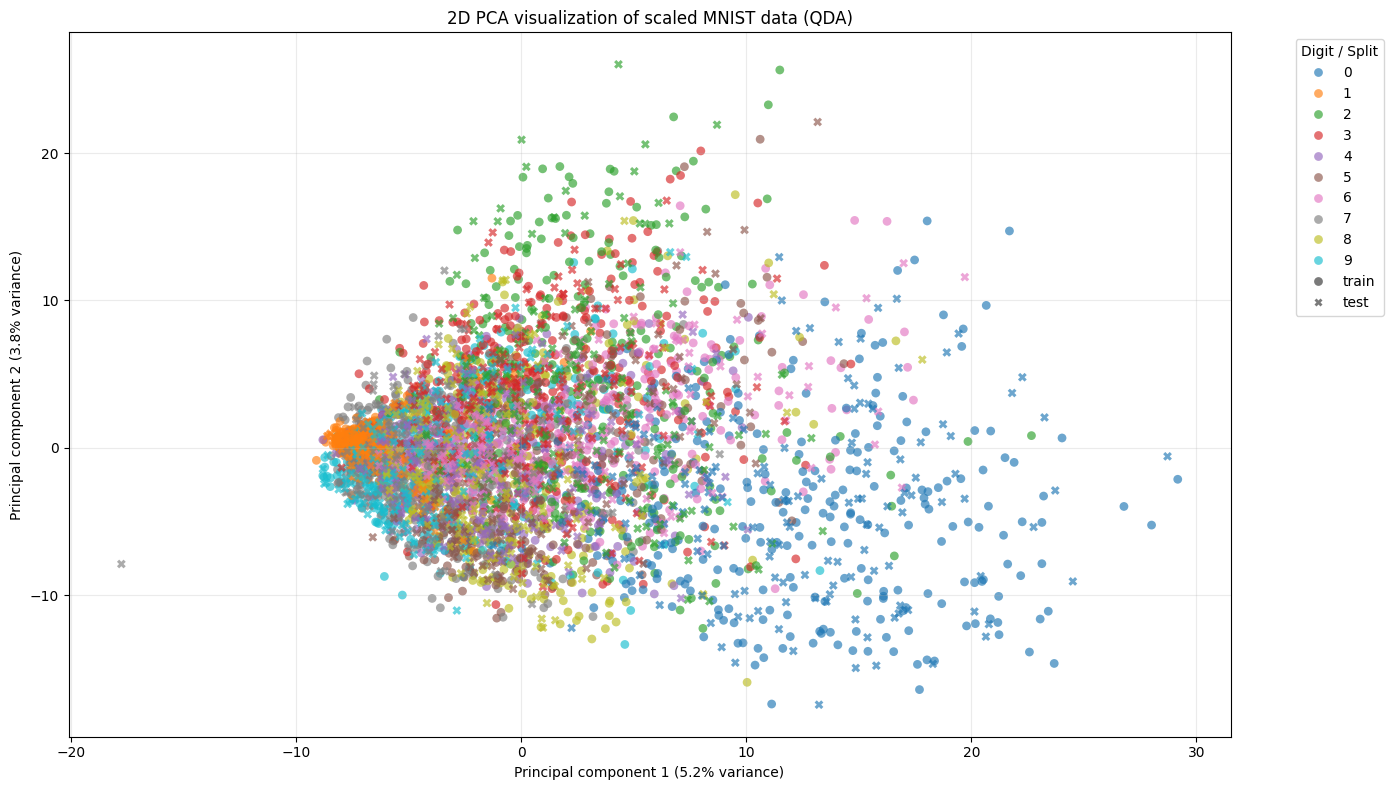

✅ 2D visualization added using PCA.
💡 The plot shows digit clusters and the train/test split on the first two components.


In [6]:
# 2D visualization of scaled data using PCA
# To keep plots readable we sample a representative subset.
rng = np.random.default_rng(42)
train_idx = rng.choice(X_train_scaled.shape[0], size=3000, replace=False)
test_idx = rng.choice(X_test_scaled.shape[0], size=1500, replace=False)

X_vis = np.vstack([X_train_scaled[train_idx], X_test_scaled[test_idx]])
y_vis = np.concatenate([y_train[train_idx], y_test[test_idx]])
split_vis = np.array(['train'] * len(train_idx) + ['test'] * len(test_idx))

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_vis_2d = pca.fit_transform(X_vis)

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    x=X_vis_2d[:, 0],
    y=X_vis_2d[:, 1],
    hue=y_vis,
    style=split_vis,
    palette='tab10',
    alpha=0.65,
    s=40,
    edgecolor='none'
)

plt.title('2D PCA visualization of scaled MNIST data (QDA)')
plt.xlabel(f'Principal component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Digit / Split', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('✅ 2D visualization added using PCA.')
print('💡 The plot shows digit clusters and the train/test split on the first two components.')

## Model evaluation
We compute accuracy and the confusion matrix to understand model errors.

In [7]:
# Predict labels on the scaled test set.
y_pred = qda.predict(X_test_scaled)

# Compute performance metrics.
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'QDA accuracy on MNIST test set: {accuracy:.4f}')
print('Classification report:')
print(classification_report(y_test, y_pred))

QDA accuracy on MNIST test set: 0.5509
Classification report:
              precision    recall  f1-score   support

           0       0.35      0.97      0.52      1381
           1       0.82      0.94      0.87      1575
           2       0.84      0.22      0.35      1398
           3       0.62      0.30      0.41      1428
           4       0.85      0.13      0.22      1365
           5       0.86      0.17      0.28      1263
           6       0.74      0.94      0.83      1375
           7       0.92      0.31      0.46      1459
           8       0.47      0.51      0.49      1365
           9       0.42      0.95      0.58      1391

    accuracy                           0.55     14000
   macro avg       0.69      0.54      0.50     14000
weighted avg       0.69      0.55      0.51     14000



## Confusion matrix analysis
The confusion matrix highlights which classes are confused, helping identify digit pairs that are hard to distinguish.

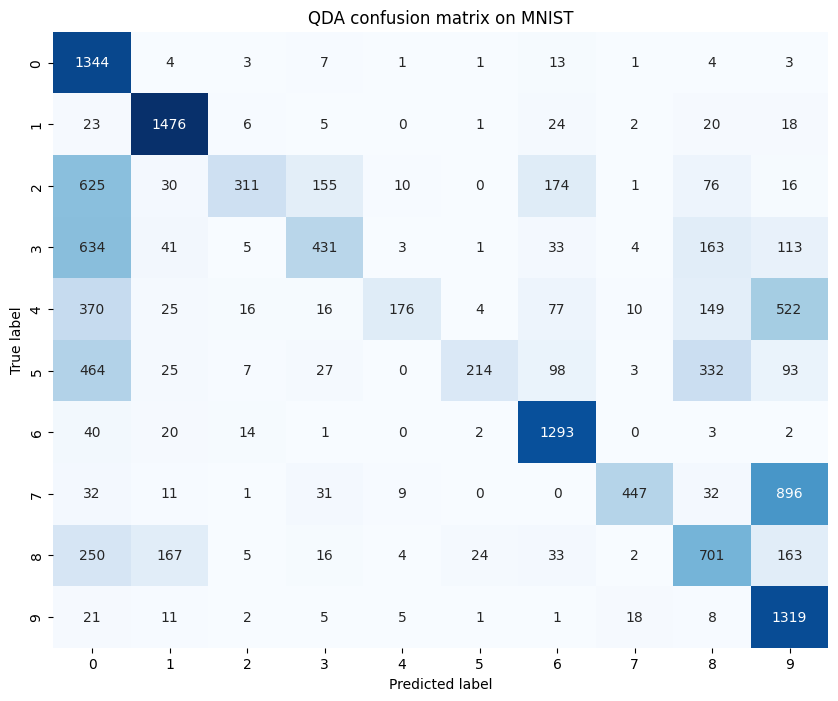

In [8]:
# Plot the confusion matrix to analyze model errors.
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('QDA confusion matrix on MNIST')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

## Summary and conclusions
- QDA is a supervised method that produces quadratic decision boundaries.
- It is particularly useful when each class has its own covariance structure.
- On the full MNIST dataset, QDA can be more costly to train but offers an interesting alternative to LDA for non-homogeneous distributions.